In [6]:


import os
import json
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, f1_score
)
from sklearn.utils import class_weight

In [7]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

RUN_CONFIG = {
    "data_dir": str(PROJECT_ROOT / "data"),
    "img_size": (224, 224),
    "batch_size": 32,
    "max_epochs": 30,
    "base_lr": 1e-4,
    "l2_reg": 1e-4,
    "dropout_rate": 0.5,
    "random_seed": 42,
    "decision_threshold": 0.5,  # revisited later via PR-curve analysis
    "run_id": datetime.datetime.now().strftime("%Y%m%d_%H%M%S"),
}

TRAIN_DIR = os.path.join(RUN_CONFIG["data_dir"], "train")
VAL_DIR   = os.path.join(RUN_CONFIG["data_dir"], "val")
TEST_DIR  = os.path.join(RUN_CONFIG["data_dir"], "test")

tf.random.set_seed(RUN_CONFIG["random_seed"])
np.random.seed(RUN_CONFIG["random_seed"])

os.makedirs("output1", exist_ok=True)

with open(f"output1/run_config_{RUN_CONFIG['run_id']}.json", "w") as f:
    json.dump(RUN_CONFIG, f, indent=2)


## Quick dataset audit
 Before touching the model, confirm what we're actually working with:
 how many images per class per split. This matters because the pneumonia
 folder is known to outnumber normal cases in this dataset, which directly
 motivates the class-weighting strategy .


In [8]:
def audit_dataset(base_path):
    counts = {}
    for split in ("train", "val", "test"):
        split_path = os.path.join(base_path, split)
        if not os.path.isdir(split_path):
            continue
        counts[split] = {}
        for label in ("NORMAL", "PNEUMONIA"):
            label_path = os.path.join(split_path, label)
            if os.path.isdir(label_path):
                counts[split][label] = len([
                    fn for fn in os.listdir(label_path)
                    if fn.lower().endswith((".jpg", ".jpeg", ".png"))
                ])
    return pd.DataFrame(counts).T


dataset_summary = audit_dataset(RUN_CONFIG["data_dir"])
print("Dataset composition by split:\n", dataset_summary, "\n")
dataset_summary.to_csv(f"output1/dataset_summary_{RUN_CONFIG['run_id']}.csv")

Dataset composition by split:
        NORMAL  PNEUMONIA
train    1341       3875
val         8          8
test      234        390 



## Exploratory Data Analysis (EDA)
 Four quick visual checks before any modeling: 
 
 (1) class balance across splits,

 (2) what the raw images actually look like per class, 

 (3) whether raw image dimensions are consistent (since everything gets resized to 224x224 downstream, it's worth knowing how much distortion that resize introduces), and 

 (4) whether Normal vs. Pneumonia differ in basic pixel
 statistics, which is a cheap sanity check before trusting the CNN to find
 a more subtle signal.

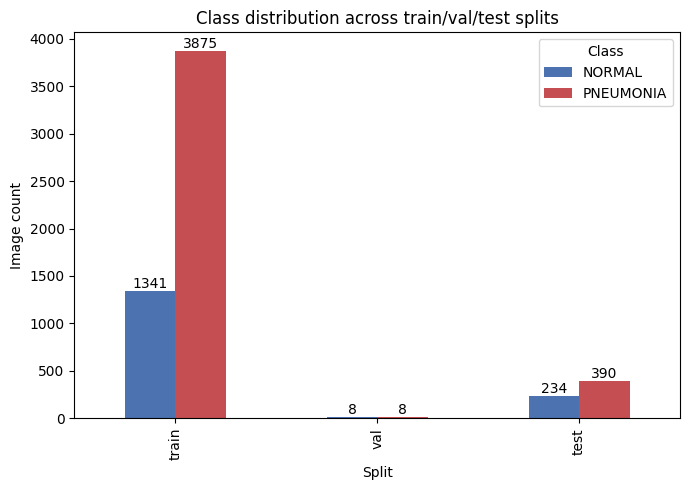

In [9]:
def plot_class_distribution(summary_df, run_id):
    fig, ax = plt.subplots(figsize=(7, 5))
    summary_df[["NORMAL", "PNEUMONIA"]].plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
    ax.set_title("Class distribution across train/val/test splits")
    ax.set_xlabel("Split")
    ax.set_ylabel("Image count")
    ax.legend(title="Class")
    for container in ax.containers:
        ax.bar_label(container, fmt="%d")
    plt.tight_layout()
    plt.savefig(f"output1/class_distribution_{run_id}.png", dpi=150)
    plt.show()


plot_class_distribution(dataset_summary, RUN_CONFIG["run_id"])

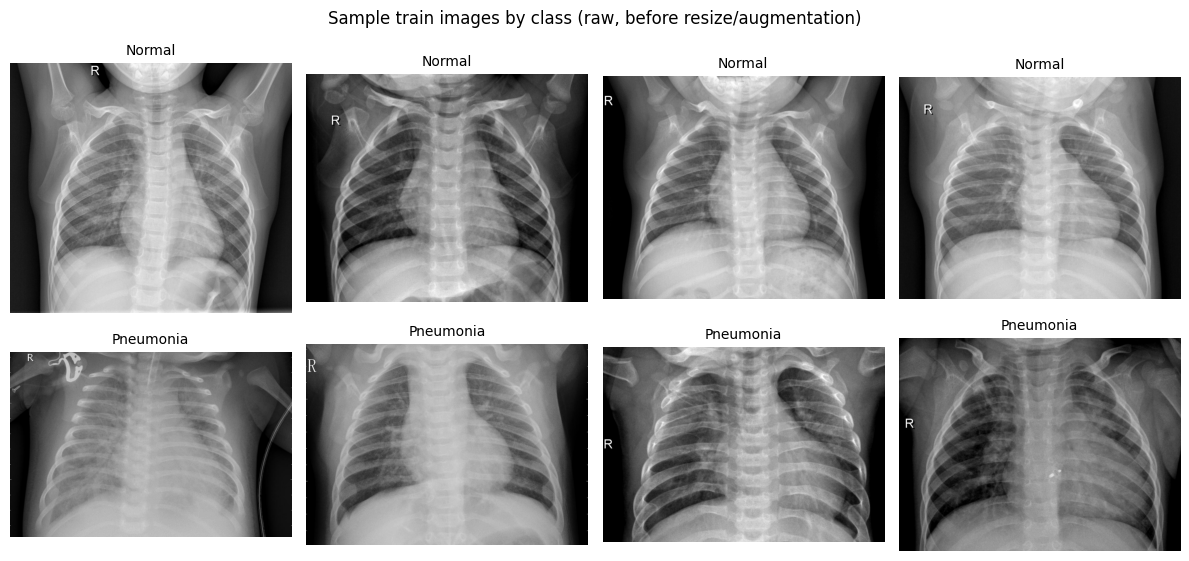

In [10]:
def plot_sample_images(base_path, run_id, split="train", n_per_class=4):
    fig, axes = plt.subplots(2, n_per_class, figsize=(3 * n_per_class, 6))
    for row, label in enumerate(("NORMAL", "PNEUMONIA")):
        label_path = os.path.join(base_path, split, label)
        filenames = sorted([
            fn for fn in os.listdir(label_path)
            if fn.lower().endswith((".jpg", ".jpeg", ".png"))
        ])[:n_per_class]
        for col, fn in enumerate(filenames):
            img = plt.imread(os.path.join(label_path, fn))
            axes[row, col].imshow(img, cmap="gray")
            axes[row, col].set_title(label.title(), fontsize=10)
            axes[row, col].axis("off")
    plt.suptitle(f"Sample {split} images by class (raw, before resize/augmentation)")
    plt.tight_layout()
    plt.savefig(f"output1/sample_images_{run_id}.png", dpi=150)
    plt.show()


plot_sample_images(RUN_CONFIG["data_dir"], RUN_CONFIG["run_id"])

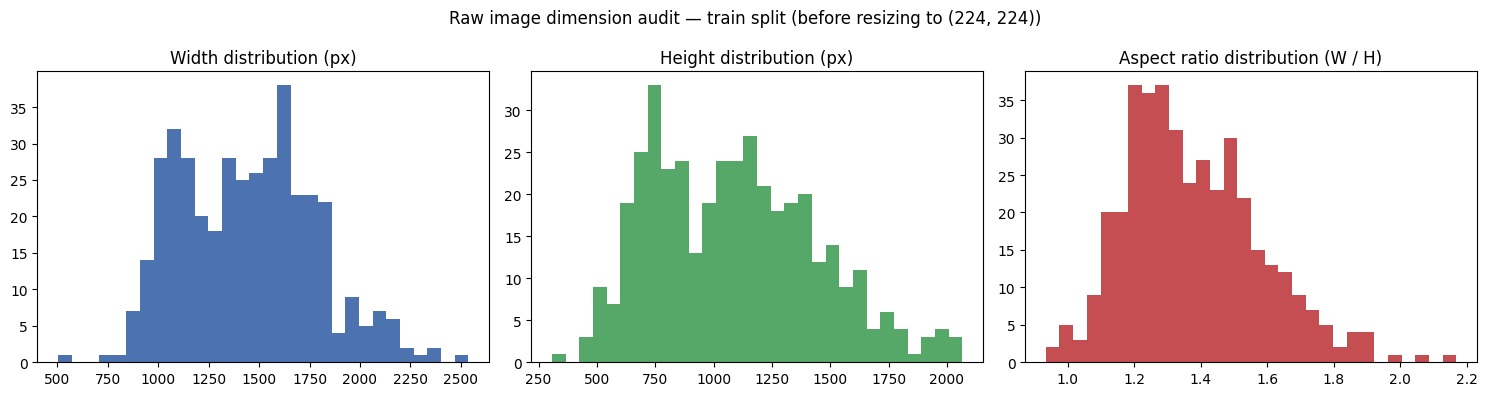

Image dimension summary by class:
            width                                                               \
           count      mean         std    min     25%     50%     75%     max   
label                                                                           
NORMAL     200.0  1651.120  260.870336  994.0  1472.0  1629.0  1801.0  2538.0   
PNEUMONIA  200.0  1233.775  266.858995  502.0  1048.0  1156.0  1370.0  2093.0   

          height            ...                  aspect_ratio            \
           count      mean  ...      75%     max        count      mean   
label                       ...                                           
NORMAL     200.0  1319.135  ...  1481.75  2066.0        200.0  1.268546   
PNEUMONIA  200.0   853.130  ...   954.00  1752.0        200.0  1.488172   

                                                                       
                std       min       25%       50%       75%       max  
label                                  

In [11]:
def audit_image_dimensions(base_path, run_id, split="train", sample_size=200):
    from PIL import Image
    rows = []
    for label in ("NORMAL", "PNEUMONIA"):
        label_path = os.path.join(base_path, split, label)
        filenames = [
            fn for fn in os.listdir(label_path)
            if fn.lower().endswith((".jpg", ".jpeg", ".png"))
        ][:sample_size]
        for fn in filenames:
            with Image.open(os.path.join(label_path, fn)) as im:
                width, height = im.size
                rows.append({"label": label, "width": width, "height": height})

    dims_df = pd.DataFrame(rows)
    dims_df["aspect_ratio"] = dims_df["width"] / dims_df["height"]
    dims_df.to_csv(f"output1/image_dimensions_{run_id}.csv", index=False)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].hist(dims_df["width"], bins=30, color="#4C72B0")
    axes[0].set_title("Width distribution (px)")
    axes[1].hist(dims_df["height"], bins=30, color="#55A868")
    axes[1].set_title("Height distribution (px)")
    axes[2].hist(dims_df["aspect_ratio"], bins=30, color="#C44E52")
    axes[2].set_title("Aspect ratio distribution (W / H)")
    fig.suptitle(f"Raw image dimension audit — {split} split "
                 f"(before resizing to {RUN_CONFIG['img_size']})")
    plt.tight_layout()
    plt.savefig(f"output1/image_dimensions_{run_id}.png", dpi=150)
    plt.show()

    print("Image dimension summary by class:\n",
          dims_df.groupby("label")[["width", "height", "aspect_ratio"]].describe(), "\n")
    return dims_df


image_dims_summary = audit_image_dimensions(RUN_CONFIG["data_dir"], RUN_CONFIG["run_id"])

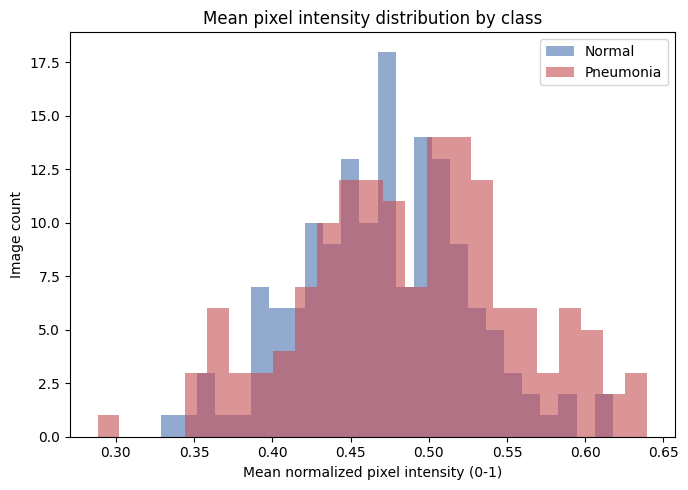

In [12]:
def plot_pixel_intensity(base_path, run_id, split="train", sample_size=150):
    from PIL import Image
    intensities = {"NORMAL": [], "PNEUMONIA": []}
    for label in ("NORMAL", "PNEUMONIA"):
        label_path = os.path.join(base_path, split, label)
        filenames = [
            fn for fn in os.listdir(label_path)
            if fn.lower().endswith((".jpg", ".jpeg", ".png"))
        ][:sample_size]
        for fn in filenames:
            with Image.open(os.path.join(label_path, fn)).convert("L") as im:
                arr = np.asarray(im, dtype=np.float32) / 255.0
                intensities[label].append(float(arr.mean()))

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.hist(intensities["NORMAL"], bins=25, alpha=0.6, label="Normal", color="#4C72B0")
    ax.hist(intensities["PNEUMONIA"], bins=25, alpha=0.6, label="Pneumonia", color="#C44E52")
    ax.set_title("Mean pixel intensity distribution by class")
    ax.set_xlabel("Mean normalized pixel intensity (0-1)")
    ax.set_ylabel("Image count")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"output1/pixel_intensity_{run_id}.png", dpi=150)
    plt.show()


plot_pixel_intensity(RUN_CONFIG["data_dir"], RUN_CONFIG["run_id"])




## Data pipelines
 Augmentation is intentionally conservative and orientation-preserving:
 a chest X-ray mirrored left-right no longer represents a valid anatomical
 view, so horizontal_flip is explicitly disabled (unlike most generic
 image-classification templates, which flip by default).
 

In [13]:

train_augmenter = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=12,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.10,
    shear_range=0.08,
    brightness_range=(0.85, 1.15),
    horizontal_flip=False,
    fill_mode="constant",
    cval=0.0,
)

eval_augmenter = ImageDataGenerator(rescale=1.0 / 255)

train_flow = train_augmenter.flow_from_directory(
    TRAIN_DIR,
    target_size=RUN_CONFIG["img_size"],
    batch_size=RUN_CONFIG["batch_size"],
    class_mode="binary",
    classes=["NORMAL", "PNEUMONIA"],
    seed=RUN_CONFIG["random_seed"],
)

val_flow = eval_augmenter.flow_from_directory(
    VAL_DIR,
    target_size=RUN_CONFIG["img_size"],
    batch_size=RUN_CONFIG["batch_size"],
    class_mode="binary",
    classes=["NORMAL", "PNEUMONIA"],
    shuffle=False,
)

test_flow = eval_augmenter.flow_from_directory(
    TEST_DIR,
    target_size=RUN_CONFIG["img_size"],
    batch_size=RUN_CONFIG["batch_size"],
    class_mode="binary",
    classes=["NORMAL", "PNEUMONIA"],
    shuffle=False,
)

print("Label mapping confirmed:", train_flow.class_indices)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Label mapping confirmed: {'NORMAL': 0, 'PNEUMONIA': 1}


##  Class imbalance correction

In [14]:

observed_labels = train_flow.classes
balanced_weights = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.unique(observed_labels),
    y=observed_labels,
)
class_weight_map = {i: w for i, w in enumerate(balanced_weights)}
print("Class weights applied during training:", class_weight_map)


Class weights applied during training: {0: 1.9448173005219984, 1: 0.6730322580645162}


##  Model architecture
 Three convolutional stages, each followed by BatchNorm + MaxPooling.
 BatchNorm is added after every conv block (not present in a bare-bones
 template) to stabilize training given the modest dataset size, and a
 light L2 penalty on the dense layer combats overfitting on top of dropout.

In [15]:

def build_pediatric_cxr_cnn(input_shape, l2_strength, dropout_rate):
    reg = regularizers.l2(l2_strength)

    inputs = layers.Input(shape=input_shape, name="cxr_input")

    x = layers.Conv2D(32, 3, padding="same", activation="relu", name="conv_block1")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, name="pool1")(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu", name="conv_block2")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, name="pool2")(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu", name="conv_block3")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, name="pool3")(x)

    x = layers.Flatten(name="flatten")(x)
    x = layers.Dense(128, activation="relu", kernel_regularizer=reg, name="dense_128")(x)
    x = layers.Dropout(dropout_rate, name="dropout")(x)
    outputs = layers.Dense(1, activation="sigmoid", name="pneumonia_probability")(x)

    return models.Model(inputs, outputs, name="pediatric_cxr_cnn")


cxr_model = build_pediatric_cxr_cnn(
    input_shape=(*RUN_CONFIG["img_size"], 3),
    l2_strength=RUN_CONFIG["l2_reg"],
    dropout_rate=RUN_CONFIG["dropout_rate"],
)

cxr_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=RUN_CONFIG["base_lr"]),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
    ],
)

cxr_model.summary()


Model: "pediatric_cxr_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ cxr_input (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_block1 (Conv2D)            │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_block2 (Conv2D)            │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_block3 (Conv2D)            │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pneumonia_probability (Dense)   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,939,457 (49.36 MB)

 Trainable params: 12,939,009 (49.36 MB)

 Non-trainable params: 448 (1.75 KB)

##  Training callbacks

In [16]:

run_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max", patience=7, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        f"output1/best_cxr_cnn_{RUN_CONFIG['run_id']}.keras",
        monitor="val_auc", mode="max", save_best_only=True,
    ),
    tf.keras.callbacks.CSVLogger(
        f"output1/training_log_{RUN_CONFIG['run_id']}.csv"
    ),
]


## Training

In [17]:

training_history = cxr_model.fit(
    train_flow,
    epochs=RUN_CONFIG["max_epochs"],
    validation_data=val_flow,
    class_weight=class_weight_map,
    callbacks=run_callbacks,
)

d:\Programs\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 265s 2s/step - accuracy: 0.8416 - auc: 0.9073 - loss: 0.4973 - precision: 0.9415 - recall: 0.8390 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 9.3916 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 247s 2s/step - accuracy: 0.8896 - auc: 0.9598 - loss: 0.2885 - precision: 0.9739 - recall: 0.8748 - val_accuracy: 0.5000 - val_auc: 0.5625 - val_loss: 6.8119 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 247s 2s/step - accuracy: 0.9070 - auc: 0.9705 - loss: 0.2456 - precision: 0.9724 - recall: 0.9004 - val_accuracy: 0.5625 - val_auc: 0.6875 - val_loss: 2.8571 - val_precision: 0.5333 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 239s 1s/step - accuracy: 0.9099 - auc: 0.9725 - loss: 0.2351 - precision: 0.9757 - recall: 0.9012 - val_accuracy: 0.6250 - val_auc: 0.9531 - val_lo

## Threshold selection via precision-recall trade-off
 Rather than blindly using 0.5, scan thresholds on the validation set and
 pick the one that maximizes F1 - this is a deliberate, justified choice
 rather than an assumed default, and it's logged for transparency.

In [18]:


val_flow.reset()
val_probs = cxr_model.predict(val_flow).ravel()
val_true = val_flow.classes

precisions, recalls, thresholds = precision_recall_curve(val_true, val_probs)
f1_scores = np.divide(
    2 * precisions * recalls,
    precisions + recalls,
    out=np.zeros_like(precisions),
    where=(precisions + recalls) != 0,
)
best_idx = np.argmax(f1_scores[:-1])  # last point has no matching threshold
selected_threshold = float(thresholds[best_idx])
RUN_CONFIG["decision_threshold"] = selected_threshold
print(f"\nThreshold selected from validation F1 sweep: {selected_threshold:.3f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step

Threshold selected from validation F1 sweep: 0.104


## Held-out test evaluation

In [19]:

test_flow.reset()
test_probs = cxr_model.predict(test_flow).ravel()
test_true = test_flow.classes
test_pred = (test_probs >= selected_threshold).astype(int)

print("\n--- Test set performance (tuned threshold) ---")
print(classification_report(test_true, test_pred, target_names=["Normal (0)", "Pneumonia (1)"]))
print("Confusion matrix:\n", confusion_matrix(test_true, test_pred))
print(f"ROC-AUC: {roc_auc_score(test_true, test_probs):.4f}")
print(f"F1 (pneumonia class): {f1_score(test_true, test_pred):.4f}")

# Also report at the naive 0.5 threshold for direct comparison
default_pred = (test_probs >= 0.5).astype(int)
print("\n--- Test set performance (naive 0.5 threshold, for comparison) ---")
print(classification_report(test_true, default_pred, target_names=["Normal (0)", "Pneumonia (1)"]))


d:\Programs\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 571ms/step

--- Test set performance (tuned threshold) ---
               precision    recall  f1-score   support

   Normal (0)       0.86      0.85      0.86       234
Pneumonia (1)       0.91      0.92      0.91       390

     accuracy                           0.89       624
    macro avg       0.89      0.89      0.89       624
 weighted avg       0.89      0.89      0.89       624

Confusion matrix:
 [[200  34]
 [ 33 357]]
ROC-AUC: 0.9582
F1 (pneumonia class): 0.9142

--- Test set performance (naive 0.5 threshold, for comparison) ---
               precision    recall  f1-score   support

   Normal (0)       0.68      0.96      0.80       234
Pneumonia (1)       0.97      0.73      0.84       390

     accuracy                           0.82       624
    macro avg       0.83      0.85      0.82       624
 weighted avg       0.86      0.82      0.82       624



## Visual diagnostics: training curves, ROC, PR curve
 Combined into one figure rather than separate plots — easier to include
 as a single exhibit in a report.

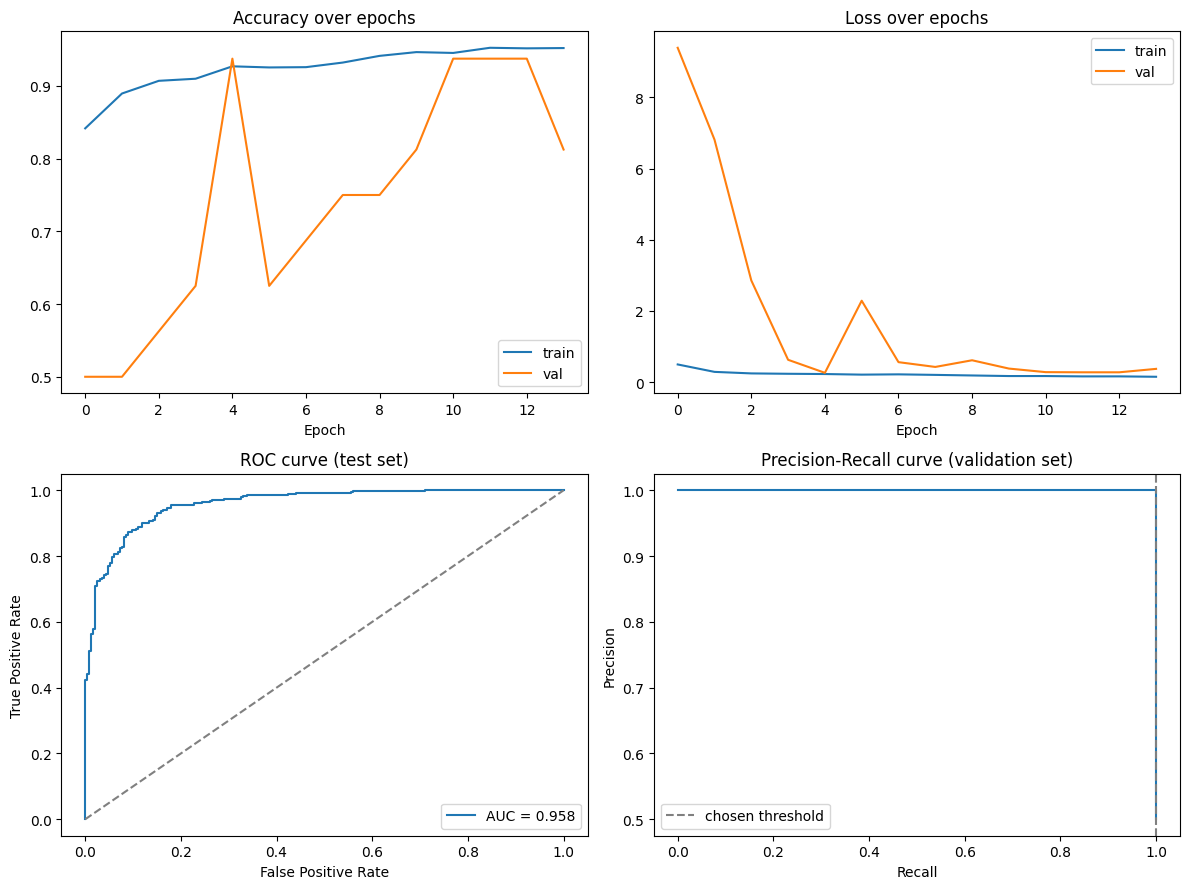

In [20]:


fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].plot(training_history.history["accuracy"], label="train")
axes[0, 0].plot(training_history.history["val_accuracy"], label="val")
axes[0, 0].set_title("Accuracy over epochs")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].legend()

axes[0, 1].plot(training_history.history["loss"], label="train")
axes[0, 1].plot(training_history.history["val_loss"], label="val")
axes[0, 1].set_title("Loss over epochs")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].legend()

fpr, tpr, _ = roc_curve(test_true, test_probs)
axes[1, 0].plot(fpr, tpr, label=f"AUC = {roc_auc_score(test_true, test_probs):.3f}")
axes[1, 0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1, 0].set_title("ROC curve (test set)")
axes[1, 0].set_xlabel("False Positive Rate")
axes[1, 0].set_ylabel("True Positive Rate")
axes[1, 0].legend()

axes[1, 1].plot(recalls, precisions)
axes[1, 1].axvline(recalls[best_idx], color="gray", linestyle="--", label="chosen threshold")
axes[1, 1].set_title("Precision-Recall curve (validation set)")
axes[1, 1].set_xlabel("Recall")
axes[1, 1].set_ylabel("Precision")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(f"output1/diagnostics_{RUN_CONFIG['run_id']}.png", dpi=150)
plt.show()


##  Grad-CAM: visualize what the CNN is looking at
 For a clinical use case, being able to show which lung regions drove a
 prediction is important for trust/explainability, and it's a good sanity
 check that the model isn't keying off image borders .

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step


d:\Programs\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['cxr_input']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


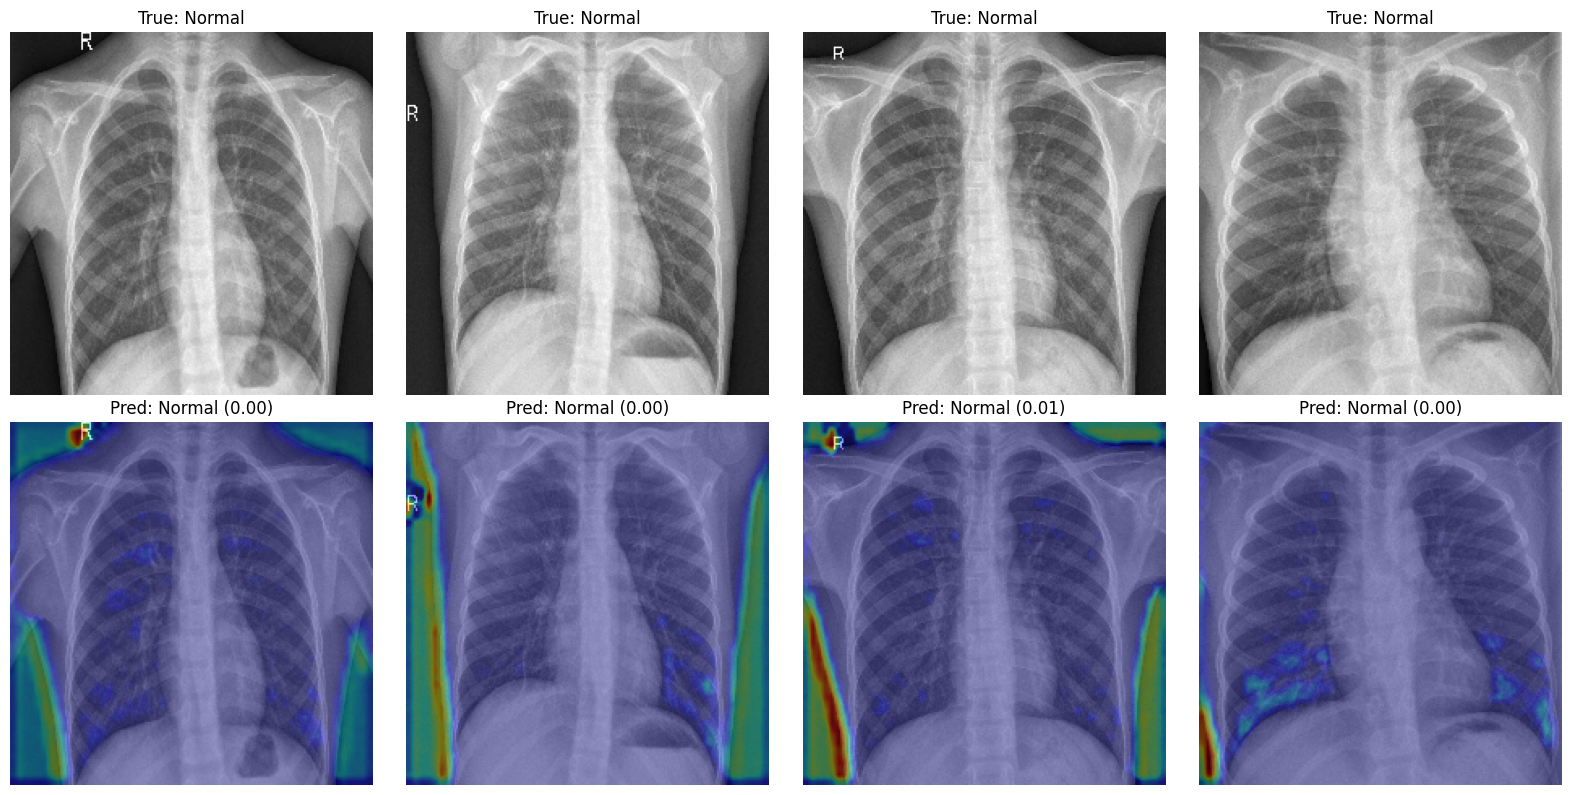

In [21]:



def compute_gradcam(model, img_array, last_conv_layer_name="conv_block3"):
    grad_model = models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def save_gradcam_examples(model, generator, threshold, n_examples=4):
    generator.reset()
    images, labels = next(generator)
    probs = model.predict(images).ravel()

    fig, axes = plt.subplots(2, n_examples, figsize=(4 * n_examples, 8))
    for i in range(n_examples):
        img = images[i:i + 1]
        heatmap = compute_gradcam(model, img)
        heatmap_resized = tf.image.resize(
            heatmap[..., tf.newaxis], RUN_CONFIG["img_size"]
        ).numpy().squeeze()

        axes[0, i].imshow(images[i])
        axes[0, i].set_title(f"True: {'Pneumonia' if labels[i]==1 else 'Normal'}")
        axes[0, i].axis("off")

        axes[1, i].imshow(images[i])
        axes[1, i].imshow(heatmap_resized, cmap="jet", alpha=0.4)
        pred_label = "Pneumonia" if probs[i] >= threshold else "Normal"
        axes[1, i].set_title(f"Pred: {pred_label} ({probs[i]:.2f})")
        axes[1, i].axis("off")

    plt.tight_layout()
    plt.savefig(f"output1/gradcam_examples_{RUN_CONFIG['run_id']}.png", dpi=150)
    plt.show()


save_gradcam_examples(cxr_model, test_flow, selected_threshold)



In [22]:

cxr_model.save(f"output1/pediatric_cxr_cnn_final_{RUN_CONFIG['run_id']}.keras")
with open(f"output1/run_config_{RUN_CONFIG['run_id']}.json", "w") as f:
    json.dump(RUN_CONFIG, f, indent=2)

print(f"\nAll output1 saved under ./output1/ with run_id={RUN_CONFIG['run_id']}")


All output1 saved under ./output1/ with run_id=20260825_180317


## Confusion matrix 
A heatmap view of the same counts printed above in the held-out test evaluation section, for quick visual inspection of false positives vs. false negatives at the tuned threshold.

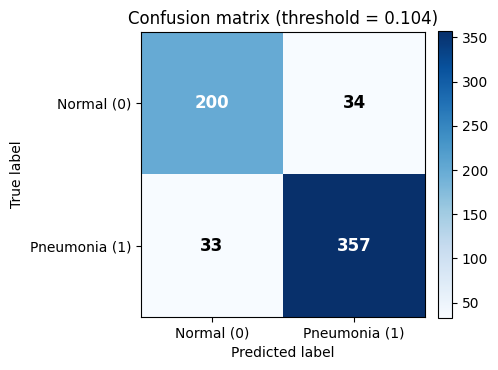

In [23]:

cm = confusion_matrix(test_true, test_pred)
class_names = ["Normal (0)", "Pneumonia (1)"]

fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title(f"Confusion matrix (threshold = {selected_threshold:.3f})")

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, format(cm[i, j], "d"),
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black",
            fontsize=12, fontweight="bold",
        )

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(f"output1/confusion_matrix_{RUN_CONFIG['run_id']}.png", dpi=150)
plt.show()